In [9]:
import numpy as np
import tensorflow as tf
import tensorflow.keras.layers as layers
import matplotlib.pyplot as plt
import math
import nibabel as nib
import os 


def global_normalized_cross_correlation_loss():
    def ncc(y_true, y_pred):
        """Computes the normalized cross-correlation (NCC) loss.

        Parameters
        ----------
        y_true : tf.Tensor
            The static image to which the moving image is aligned.
        y_pred : tf.Tensor
            The moving image, the same shape as the static image.

        Returns
        -------
        loss : tf.Tensor, shape ()
            Normalized cross-correlation loss between the static and the
            moving images, averaged over the batch. Range is [-1.0, 1.0].
            The best value is -1 (perfect match) and the worst is 1.

        References
        ----------
        .. [1] `Wikipedia entry for the Cross-correlation
               <https://en.wikipedia.org/wiki/Cross-correlation>`_

        """
        ndim = tf.keras.backend.ndim(y_true)-2

        # shape (N, 1, 1, C)
        y_true_mean = tf.reduce_mean(y_true, axis=range(1, ndim+1),
                                     keepdims=True)
        y_pred_mean = tf.reduce_mean(y_pred, axis=range(1, ndim+1),
                                     keepdims=True)
        plt.ylabel('Loss')

        y_true_hat = tf.math.l2_normalize(y_true-y_true_mean,
                                          axis=range(1, ndim+1))

        y_pred_hat = tf.math.l2_normalize(y_pred-y_pred_mean,
                                          axis=range(1, ndim+1))

        return -tf.reduce_mean(tf.reduce_sum(y_true_hat * y_pred_hat,
                                             axis=range(1, ndim+1)))
    return ncc


def local_normalized_cross_correlation_loss(window=(9, 9, 9), eps=1e-5):
    """
    Code borrowed from https://github.com/voxelmorph/voxelmorph/blob/legacy/src/losses.py#L28
    Paper: https://openaccess.thecvf.com/content_cvpr_2018/papers/Balakrishnan_An_Unsupervised_Learning_CVPR_2018_paper.pdf
    """
    def ncc(I, J, window=window):
        # get dimension of volume
        # assumes I, J are sized [batch_size, *vol_shape, nb_feats]
        # ndims = len(I.get_shape().as_list()) - 2
        ndims = tf.keras.backend.ndim(I)-2
        assert ndims in [1, 2, 3], "volumes should be 1 to 3 dimensions. found: %d" % ndims

        # set window size
        if window is None:
            window = [9] * ndims

        # get convolution function
        conv_fn = getattr(tf.nn, 'conv%dd' % ndims)

        # compute CC squares
        I2 = I*I
        J2 = J*J
        IJ = I*J

        # compute filters
        sum_filt = tf.ones([*window, 1, 1])
        strides = [1] * (ndims + 2)
        padding = 'SAME'

        # compute local sums via convolution
        I_sum = conv_fn(I, sum_filt, strides, padding)
        J_sum = conv_fn(J, sum_filt, strides, padding)
        I2_sum = conv_fn(I2, sum_filt, strides, padding)
        J2_sum = conv_fn(J2, sum_filt, strides, padding)
        IJ_sum = conv_fn(IJ, sum_filt, strides, padding)

        # compute cross correlation
        win_size = np.prod(window)
        u_I = I_sum/win_size
        u_J = J_sum/win_size

        cross = IJ_sum - u_J*I_sum - u_I*J_sum + u_I*u_J*win_size
        I_var = I2_sum - 2 * u_I * I_sum + u_I*u_I*win_size
        J_var = J2_sum - 2 * u_J * J_sum + u_J*u_J*win_size

        cc = cross*cross / (I_var*J_var + eps)

        # return negative cc.
        return -tf.reduce_mean(cc)
    return ncc

# vein. Portal veins are well enhanced and some enhancement of the hepatic veins is also seen on the portal venous phase. T
def gradient_loss(norm=2):
    """
    Code borrowed from https://github.com/voxelmorph/voxelmorph/blob/legacy/pytorch/losses.py#L13
    Paper: https://openaccess.thecvf.com/content_cvpr_2018/papers/Balakrishnan_An_Unsupervised_Learning_CVPR_2018_paper.pdf
    """
    def grad_loss(_, phi):
        di = tf.abs(phi[:, 1:, :, :, :] - phi[:, :-1, :, :, :])
        dj = tf.abs(phi[:, :, 1:, :, :] - phi[:, :, :-1, :, :])
        dk = tf.abs(phi[:, :, :, 1:, :] - phi[:, :, :, :-1, :])

        loss = tf.reduce_mean(di) + tf.reduce_mean(dj) + tf.reduce_mean(dk)
        if norm == 2:
            loss = tf.reduce_mean(di**2) + tf.reduce_mean(dj**2) + tf.reduce_mean(dk**2)    
        return loss
    return grad_loss

def regular_grid_3d(depth, height, width):
    """Returns a 3-D regular grid.

    Parameters
    ----------
    depth : int
        The desired depth of the grid.
    height : int
        The desired height of the grid.
    width : int
        The desired width of the grid.
    Returns
    -------
    grid : tf.Tensor, shape (D, H, W, 3)
        A 3-D regular grid, values normalized to [-1.0, 1.0]
        range.

    Notes
    -----
    Sampling using the regular grid is an identity transformation, i.e.,
    it results in the same input and output images.

    References
    ----------
    .. [1] `NumPy, "numpy.meshgrid"
        <https://numpy.org/doc/stable/reference/generated/numpy.meshgrid.html>`_
    .. [2] `NumPy, "numpy.indices"
        <https://numpy.org/doc/stable/reference/generated/numpy.indices.html>`_

    """
    i = tf.linspace(-1.0, 1.0, depth)
    j = tf.linspace(-1.0, 1.0, height)
    k = tf.linspace(-1.0, 1.0, width)

    I, J, K = tf.meshgrid(i, j, k, indexing='ij')

    grid = tf.stack([I, J, K], axis=-1)
    return grid


def grid_sample_3d(moving, grid, name=None):
    """Given a moving image and a sampling grid as input, computes the
    transformed image by sampling the moving image at locations given by
    the grid.

    Parameters
    ----------
    moving : tf.Tensor, shape (N, D, H, W, C)
        The moving image.
    grid : tf.Tensor, shape (N, D, H, W, C)
        A tensor of sampling points (x, y, z). The x, y and z values should be
        normalized to [-1.0, 1.0] range.
    name : str
        Name for the operation.

    Returns
    -------
    moved : tf.Tensor, shape (N, D, H, W, C)
        The transformed image.

    Notes
    -----
    Let M be the moving image of shape (H, W, C), T be the transformed
    image of the same shape and G be the 2D sampling grid of shape
    (H, W, 2). The value of T at a location (x, y) is T[y, x, :] =
    M[y', x', :] where [x', y'] = G[y, x, :].

    Further, [x', y'] = [x + dx, y + dy] where [dx, dy] are the
    displacements outputted by the CNN. When dx and dy are 0, the
    sampling grid G is a regular grid and the transformed image is the
    same as the moving image.

    Since the sampling point (x + dx, y + dy) can be non-integral, the
    value M[y', x'] is calculated using bi-linear interpolation.

    References
    ----------
    .. [1] `Jaderberg, Max, Karen Simonyan, and Andrew Zisserman. "Spatial
        transformer networks." Advances in neural information processing
        systems. 2015. <https://arxiv.org/abs/1506.02025>`_
    .. [2] `TensorFlow implementation of spatial transformer networks.
        <https://github.com/tensorflow/models/tree/master/research/transformer>`_
    .. [3] `Spatial Transformer Networks by Kushagra Bhatnagar
        <https://link.medium.com/0b2OrmqVO5>`_
        
    """
    nb, nd, nh, nw, nc = tf.shape(moving)
    
    i = grid[..., 0]  # shape (N, D, H, W)
    j = grid[..., 1]
    k = grid[..., 2]
    i = tf.cast(i, 'float32')
    j = tf.cast(j, 'float32')
    k = tf.cast(k, 'float32')

    # Scale i, j and k from [-1.0, 1.0] to [0, D], [0, H] and [0, W] respectively.
    i = (i + 1.0) * 0.5 * tf.cast(nd-1, 'float32')
    j = (j + 1.0) * 0.5 * tf.cast(nh-1, 'float32')
    k = (k + 1.0) * 0.5 * tf.cast(nw-1, 'float32')

    i_max = tf.cast(nd - 1, 'int32')
    j_max = tf.cast(nh - 1, 'int32')
    k_max = tf.cast(nw - 1, 'int32')
    zero = tf.constant(0, 'int32')

    # The value at (i, j, k) is a weighted average of the values at the
    # eight nearest integer locations: (i0, j0, k0), (i0, j0, k1), (i0, j1, k0),
    # (i0, j1, k1), (i1, j0, k0), (i1, j0, k1), (i1, j1, k0) and (i1, j1, k1)
    # where i0 = floor(i), i1 = ceil(i).
    i0 = tf.cast(tf.floor(i), 'int32')
    i1 = i0 + 1
    j0 = tf.cast(tf.floor(j), 'int32')
    j1 = j0 + 1
    k0 = tf.cast(tf.floor(k), 'int32')
    k1 = k0 + 1

    # Make sure indices are within the boundaries of the image.
    i0 = tf.clip_by_value(i0, zero, i_max)
    i1 = tf.clip_by_value(i1, zero, i_max)
    j0 = tf.clip_by_value(j0, zero, j_max)
    j1 = tf.clip_by_value(j1, zero, j_max)
    k0 = tf.clip_by_value(k0, zero, k_max)
    k1 = tf.clip_by_value(k1, zero, k_max)

    # Collect indices of the four corners.
    b = tf.ones_like(i0) * tf.reshape(tf.range(nb), [nb, 1, 1, 1])
    idx_a = tf.stack([b, i1, j0, k0], axis=-1)  # all front-top-left corners
    idx_b = tf.stack([b, i1, j1, k0], axis=-1)  # all front-bottom-left corners
    idx_c = tf.stack([b, i1, j0, k1], axis=-1)  # all front-top-right corners
    idx_d = tf.stack([b, i1, j1, k1], axis=-1)  # all front-bottom-right corners
    idx_e = tf.stack([b, i0, j0, k0], axis=-1)  # all back-top-left corners
    idx_f = tf.stack([b, i0, j1, k0], axis=-1)  # all back-bottom-left corners
    idx_g = tf.stack([b, i0, j0, k1], axis=-1)  # all back-top-right corners
    idx_h = tf.stack([b, i0, j1, k1], axis=-1)  # all back-bottom-right corners
    # shape (N, D, H, W, 3)

    # Collect values at the corners.
    moving_a = tf.gather_nd(moving, idx_a)  # all front-top-left values
    moving_b = tf.gather_nd(moving, idx_b)  # all front-bottom-left values
    moving_c = tf.gather_nd(moving, idx_c)  # all front-top-right values
    moving_d = tf.gather_nd(moving, idx_d)  # all front-bottom-right values
    moving_e = tf.gather_nd(moving, idx_e)  # all back-top-left values
    moving_f = tf.gather_nd(moving, idx_f)  # all back-bottom-left values
    moving_g = tf.gather_nd(moving, idx_g)  # all back-top-right values
    moving_h = tf.gather_nd(moving, idx_h)  # all back-bottom-right values
    # shape (N, D, H, W, C)

    i0_f = tf.cast(i0, 'float32')
    i1_f = tf.cast(i1, 'float32')
    j0_f = tf.cast(j0, 'float32')
    j1_f = tf.cast(j1, 'float32')
    k0_f = tf.cast(k0, 'float32')
    k1_f = tf.cast(k1, 'float32')

    # Calculate the weights.
    wa = tf.expand_dims((i - i0_f) * (j1_f - j) * (k1_f - k), axis=-1)
    wb = tf.expand_dims((i - i0_f) * (j - j0_f) * (k1_f - k), axis=-1)
    wc = tf.expand_dims((i - i0_f) * (j1_f - j) * (k - k0_f), axis=-1)
    wd = tf.expand_dims((i - i0_f) * (j - j0_f) * (k - k0_f), axis=-1)
    we = tf.expand_dims((i1_f - i) * (j1_f - j) * (k1_f - k), axis=-1)
    wf = tf.expand_dims((i1_f - i) * (j - j0_f) * (k1_f - k), axis=-1)
    wg = tf.expand_dims((i1_f - i) * (j1_f - j) * (k - k0_f), axis=-1)
    wh = tf.expand_dims((i1_f - i) * (j - j0_f) * (k - k0_f), axis=-1)

    # Calculate the weighted sum.
    moved = tf.add_n([wa * moving_a, wb * moving_b, wc * moving_c,
                      wd * moving_d, we * moving_e, wf * moving_f,
                      wg * moving_g, wh * moving_h], name=name)
    return moved

class VoxelMorph1(object):
    def __init__(self, input_shape=(32, 32, 1), optimizer='adam', loss=None,
                 metrics=None, loss_weights=None):
        in_channels = 1
        out_channels = 3
        input_shape = input_shape + (in_channels,)

        moving = layers.Input(shape=input_shape, name='moving')
        static = layers.Input(shape=input_shape, name='static')
        
        
        x_in = layers.concatenate([static, moving], axis=-1)

        # encoder
        x1 = layers.Conv3D(16, kernel_size=3, strides=2, padding='same',
                           kernel_initializer='he_normal')(x_in)
        x1 = layers.LeakyReLU(alpha=0.2)(x1)  # 16

        x2 = layers.Conv3D(32, kernel_size=3, strides=2, padding='same',
                           kernel_initializer='he_normal')(x1)
        x2 = layers.LeakyReLU(alpha=0.2)(x2)  # 8

        x3 = layers.Conv3D(32, kernel_size=3, strides=2, padding='same',
                           kernel_initializer='he_normal')(x2)
        x3 = layers.LeakyReLU(alpha=0.2)(x3)  # 4

        x4 = layers.Conv3D(32, kernel_size=3, strides=2, padding='same',
                           kernel_initializer='he_normal')(x3)
        x4 = layers.LeakyReLU(alpha=0.2)(x4)  # 2

        # decoder [32, 32, 32, 32, 8, 8]
        x = layers.Conv3D(32, kernel_size=3, strides=1, padding='same',
                          kernel_initializer='he_normal')(x4)
        x = layers.LeakyReLU(alpha=0.2)(x)
        x = layers.UpSampling3D(size=2)(x)  # 4
        x = layers.concatenate([x, x3], axis=-1)  # 4

        x = layers.Conv3D(32, kernel_size=3, strides=1, padding='same',
                          kernel_initializer='he_normal')(x)
        x = layers.LeakyReLU(alpha=0.2)(x)
        x = layers.UpSampling3D(size=2)(x)  # 8
        x = layers.concatenate([x, x2], axis=-1)  # 8

        x = layers.Conv3D(32, kernel_size=3, strides=1, padding='same',
                          kernel_initializer='he_normal')(x)
        x = layers.LeakyReLU(alpha=0.2)(x)
        x = layers.UpSampling3D(size=2)(x)  # 16
        x = layers.concatenate([x, x1], axis=-1)  # 16

        x = layers.Conv3D(32, kernel_size=3, strides=1, padding='same',
                          kernel_initializer='he_normal')(x)
        x = layers.LeakyReLU(alpha=0.2)(x)

        x = layers.Conv3D(8, kernel_size=3, strides=1, padding='same',
                          kernel_initializer='he_normal')(x)
        x = layers.LeakyReLU(alpha=0.2)(x)  # 16

        x = layers.UpSampling3D(size=2)(x)  # 32
        x = layers.concatenate([x, x_in], axis=-1)
        x = layers.Conv3D(8, kernel_size=3, strides=1, padding='same',
                          kernel_initializer='he_normal')(x)
        feature_maps = x
        x = layers.LeakyReLU(alpha=0.2)(x)  # 32

        kernel_initializer = tf.keras.initializers.RandomNormal(mean=0.0,
                                                                stddev=1e-5)
        deformation = layers.Conv3D(out_channels, kernel_size=3, strides=1,
                                    padding='same',
                                    kernel_initializer=kernel_initializer,
                                    name='deformation')(x)

        # print(deformation.shape)
        nb, nd, nh, nw, nc = tf.shape(deformation)

        # Regular grid.
        grid = regular_grid_3d(nd, nh, nw)  # shape (D, H, W, 2)
        # print(grid.shape)
        grid = tf.expand_dims(grid, axis=0)  # shape (1, D, H, W, 2)
        multiples = tf.stack([nb, 1, 1, 1, 1])
        grid = tf.tile(grid, multiples)

        # Compute the new sampling grid.moved
        grid_new = grid + deformation
        grid_new = tf.clip_by_value(grid_new, -1, 1)
        # print(grid_new.shape)

        # Sample the moving image using the new sampling grid.
        moved = grid_sample_3d(moving, grid_new, name='moved')
        
        model = tf.keras.Model(inputs={'moving': moving, 'static': static},
                               outputs={'moved': moved, 'deformation': deformation}, name='voxelmorph1')
        model.compile(optimizer=optimizer, loss=loss, metrics=metrics,
                      loss_weights=loss_weights)
        
        self.model = model

    def compile(self, optimizer='adam', loss=None, metrics=None,
                loss_weights=None):
        self.model.compile(optimizer=optimizer, loss=loss, metrics=metrics,
                           loss_weights=loss_weights)

    def summary(self):
        return self.model.summary()

    def fit(self, x=None, y=None, batch_size=None, epochs=1, verbose=1,
            callbacks=None, validation_split=0.0, validation_data=None,
            shuffle=True, initial_epoch=0, steps_per_epoch=None,
            validation_steps=None, validation_batch_size=None,
            validation_freq=1, max_queue_size=10, workers=1,
            use_multiprocessing=False):
        return self.model.fit(x=x, y=y, batch_size=batch_size,
                              epochs=epochs, verbose=verbose,
                              callbacks=callbacks,
                              validation_split=validation_split,
                              validation_data=validation_data, shuffle=shuffle,
                              initial_epoch=initial_epoch,
                              steps_per_epoch=steps_per_epoch,
                              validation_steps=validation_steps,
                              validation_batch_size=validation_batch_size,
                              validation_freq=validation_freq,
                              max_queue_size=max_queue_size, workers=workers,
                              use_multiprocessing=use_multiprocessing)

    def evaluate(self, x=None, y=None, batch_size=None, verbose=1,
                 steps=None, callbacks=None, max_queue_size=10, workers=1,
                 use_multiprocessing=False, return_dict=False):
        return self.model.evaluate(x=x, y=y, batch_size=batch_size,
                                   verbose=verbose, steps=steps,
                                   callbacks=callbacks,
                                   max_queue_size=max_queue_size,
                                   workers=workers,
                                   use_multiprocessing=use_multiprocessing,
                                   return_dict=return_dict)

    def predict(self, x, batch_size=None, verbose=0,
                steps=None, callbacks=None, max_queue_size=10, workers=1,
                use_multiprocessing=False):
        return self.model.predict(x=x, batch_size=batch_size,
                                  verbose=verbose, steps=steps,
                                  callbacks=callbacks,
                                  max_queue_size=max_queue_size,
                                  workers=workers,
                                  use_multiprocessing=use_multiprocessing)

    def save_weights(self, filepath, overwrite=True):
        self.model.save_weights(filepath=filepath, overwrite=overwrite, save_format=None)

    def load_weights(self, filepath):
        self.model.load_weights(filepath)
        
class RegistrationDataLoader(tf.keras.utils.Sequence):
    def __init__(self, moving, static, batch_size=8, shuffle=False):
        """Data loader object that fetches and preprocess batches of images 
        for real-time data feeding to the model.

        Currently supports only numpy arrays as input.
    
        Parameters
        ----------
        moving : ndarray, shape (N, ..., C)
            An array of all the moving images. N is the number of images.
        static : ndarray, shape (1, ..., C)
            The static image.

        """
        self.moving = moving
        self.static = static
        self.batch_size = batch_size
        self.shuffle = shuffle

        if self.shuffle:
            np.random.shuffle(self.moving)

    def __len__(self):
        return math.ceil(len(self.moving) / self.batch_size)

    def __getitem__(self, idx):
        moving = self.moving[idx * self.batch_size: (idx+1) * self.batch_size]
        static = np.repeat(self.static, repeats=moving.shape[0], axis=0)

        return {'moving': moving, 'static': static}, static  # input and output

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.moving)

In [10]:
# 일단 voxelmorph를 freeze 시켜놓고 그것의 output을 Discriminator network로 학습하자
# 나중에는 Adversarial Learning으로 변화해야 함..!

def voxelmorph_result_():

    def seg_mm(data1, data2):

        out_put = model.predict(data1)
        out_put = out_put['moved']
    
    return out_put, data2

In [6]:
pip install -U tensorflow-addons


     |████████████████████████████████| 1.1 MB 7.3 MB/s            
Note: you may need to restart the kernel to use updated packages.


In [7]:
import tensorflow_addons as tfa

/usr/local/lib/python3.6/dist-packages/tensorflow_addons/utils/ensure_tf_install.py:67: UserWarning: Tensorflow Addons supports using Python ops for all Tensorflow versions above or equal to 2.4.0 and strictly below 2.7.0 (nightly versions are not supported). 
 The versions of TensorFlow you are currently using is 2.3.0 and is not supported. 
Some things might work, some things might not.
If you were to encounter a bug, do not file an issue.
If you want to make sure you're using a tested and supported configuration, either change the TensorFlow version or the TensorFlow Addons's version. 
You can find the compatibility matrix in TensorFlow Addon's readme:
https://github.com/tensorflow/addons
  UserWarning,


In [8]:
# Discriminator
def Discriminator (input_shape = (64,128,128)):
    
    input_channels = 1 
    input_shape = input_shape + (input_channels,)
    
    inputs = input_shape
    targets = input_shape
    
    Nfilter_start = 64
    depth = 3
    ks = 4

    def encoder_step(layer, Nf, norm=True):
        x = layers.Conv3D(Nf, kernel_size=ks, strides=2, kernel_initializer='he_normal', padding='same')(layer)
        if norm:
            x = tfa.InstanceNormalization()(x)
        x = layers.LeakyReLU()(x)
        x = layers.Dropout(0.2)(x)
        return x

    x = layers.concatenate()([inputs, targets])

    for d in range(depth):
        if d==0:
            x = encoder_step(x, Nfilter_start*np.power(2,d), False)
        else:
            x = encoder_step(x, Nfilter_start*np.power(2,d))
            
    x = layers.ZeroPadding3D()(x)
    x = layers.Conv3D(Nfilter_start*(2**depth), ks, strides=1, padding='valid', kernel_initializer='he_normal')(x) 
    x = tfa.InstanceNormalization()(x)
    x = layers.LeakyReLU()(x)
      
    x = layers.ZeroPadding3D()(x)
    last = layers.Conv3D(1, ks, strides=1, padding='valid', kernel_initializer='he_normal', name='output_discriminator')(x) 

    return Model(inputs=[targets, inputs], outputs=last, name='Discriminator')


In [12]:
batch_size = 4
epochs = 50
lr = 0.001  # learning rate
lamda = 1  # (lambda) regularization parameter
input_shape = (64, 128, 128)

In [13]:
# 0~1 사이로 정규화 
import nibabel as nib
import os 

# filename = "./mix_data/mixed_affine.nii.gz"
# filename2 = "./static_data_exis/7.nii.gz"
filename = "./BTCV_Data/resize_exis_stack.nii.gz"
filename2 = "./BTCV_Data/static_exis/40.nii.gz"
# filename3 = "./chaos_train_voxel/gt_resize/24.nii.gz"

data = nib.load(filename).get_fdata()
static = nib.load(filename2).get_fdata()

min_value = np.min(data)
max_value = np.max(data)

data = (data-min_value) / (max_value-min_value)
print(min_value)
print(max_value)

-3024.0
3095.0


In [14]:
x_train = data[:26, ...][..., None]
x_train = x_train.astype(np.float32) 
x_test = data[26:, ...][..., None]
x_test = x_test.astype(np.float32)
x_sample = data[0:2, ...].copy()  # some images to visualize results

static = (static-min_value) / (max_value-min_value)
static = static[None, ..., None]
static = static.astype(np.float32)

print('Train: ', x_train.shape) 
print('Test: ', x_test.shape)
print('Sample: ', x_sample.shape)
print('Static: ', static.shape)

train_loader = RegistrationDataLoader(x_train, static, batch_size=batch_size,
                                      shuffle=True)
test_loader = RegistrationDataLoader(x_test, static, batch_size=batch_size,
                                     shuffle=True)
sample_loader = RegistrationDataLoader(x_sample, static, shuffle=False)

Train:  (26, 64, 128, 128, 1)
Test:  (3, 64, 128, 128, 1)
Sample:  (2, 64, 128, 128)
Static:  (1, 64, 128, 128, 1)


In [15]:
ncc_loss = local_normalized_cross_correlation_loss()
grad_loss = gradient_loss()

# Map model outputs to the loss functions and loss weights
loss_weights = {'moved': 1.0, 'deformation': lamda}
losses = {'moved': ncc_loss, 'deformation': grad_loss}

optimizer = tf.keras.optimizers.Adam(learning_rate=lr)

model = VoxelMorph1(input_shape=input_shape, optimizer=optimizer,
                    loss=losses, loss_weights=loss_weights)

In [16]:
import tensorflow

early_stop = tensorflow.keras.callbacks.EarlyStopping(monitor="val_loss", min_delta=0, patience=200, restore_best_weights=True) 
checkpoint_path = "./check_points/0727_voxelmorphcp.ckpt"
checkpoint_dir = os.path.dirname(checkpoint_path)

cp_callback = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_path,
                                   save_weights_only=True,
                                   verbose=1)# Train the model with the new callback

In [17]:
hist = model.fit(train_loader, epochs=epochs, validation_data=test_loader, callbacks=[cp_callback, early_stop])

Epoch 1/50
7/7 [==============================] - ETA: 0s - loss: -0.2397 - deformation_loss: 5.1843e-05 - tf_op_layer_moved_loss: -0.2398
Epoch 00001: saving model to ./check_points/0727_voxelmorphcp.ckpt
7/7 [==============================] - 5s 679ms/step - loss: -0.2397 - deformation_loss: 5.1843e-05 - tf_op_layer_moved_loss: -0.2398 - val_loss: -0.1971 - val_deformation_loss: 6.9506e-05 - val_tf_op_layer_moved_loss: -0.1972
Epoch 2/50
7/7 [==============================] - ETA: 0s - loss: -0.2478 - deformation_loss: 1.0314e-04 - tf_op_layer_moved_loss: -0.2479
Epoch 00002: saving model to ./check_points/0727_voxelmorphcp.ckpt
7/7 [==============================] - 3s 454ms/step - loss: -0.2478 - deformation_loss: 1.0314e-04 - tf_op_layer_moved_loss: -0.2479 - val_loss: -0.1879 - val_deformation_loss: 0.0087 - val_tf_op_layer_moved_loss: -0.1966
Epoch 3/50
7/7 [==============================] - ETA: 0s - loss: -0.2524 - deformation_loss: 0.0017 - tf_op_layer_moved_loss: -0.2541
Epo

7/7 [==============================] - ETA: 0s - loss: -0.3199 - deformation_loss: 0.0031 - tf_op_layer_moved_loss: -0.3230
Epoch 00020: saving model to ./check_points/0727_voxelmorphcp.ckpt
7/7 [==============================] - 3s 445ms/step - loss: -0.3199 - deformation_loss: 0.0031 - tf_op_layer_moved_loss: -0.3230 - val_loss: -0.3010 - val_deformation_loss: 0.0021 - val_tf_op_layer_moved_loss: -0.3031
Epoch 21/50
7/7 [==============================] - ETA: 0s - loss: -0.3421 - deformation_loss: 0.0021 - tf_op_layer_moved_loss: -0.3442
Epoch 00021: saving model to ./check_points/0727_voxelmorphcp.ckpt
7/7 [==============================] - 3s 451ms/step - loss: -0.3421 - deformation_loss: 0.0021 - tf_op_layer_moved_loss: -0.3442 - val_loss: -0.3072 - val_deformation_loss: 0.0032 - val_tf_op_layer_moved_loss: -0.3104
Epoch 22/50
7/7 [==============================] - ETA: 0s - loss: -0.3497 - deformation_loss: 0.0026 - tf_op_layer_moved_loss: -0.3523
Epoch 00022: saving model to ./c

Epoch 40/50
7/7 [==============================] - ETA: 0s - loss: -0.4372 - deformation_loss: 0.0038 - tf_op_layer_moved_loss: -0.4409
Epoch 00040: saving model to ./check_points/0727_voxelmorphcp.ckpt
7/7 [==============================] - 3s 450ms/step - loss: -0.4372 - deformation_loss: 0.0038 - tf_op_layer_moved_loss: -0.4409 - val_loss: -0.3964 - val_deformation_loss: 0.0043 - val_tf_op_layer_moved_loss: -0.4006
Epoch 41/50
7/7 [==============================] - ETA: 0s - loss: -0.4383 - deformation_loss: 0.0037 - tf_op_layer_moved_loss: -0.4420
Epoch 00041: saving model to ./check_points/0727_voxelmorphcp.ckpt
7/7 [==============================] - 3s 453ms/step - loss: -0.4383 - deformation_loss: 0.0037 - tf_op_layer_moved_loss: -0.4420 - val_loss: -0.4014 - val_deformation_loss: 0.0045 - val_tf_op_layer_moved_loss: -0.4059
Epoch 42/50
7/7 [==============================] - ETA: 0s - loss: -0.4493 - deformation_loss: 0.0040 - tf_op_layer_moved_loss: -0.4534
Epoch 00042: saving 

In [ ]:
checkpoint_path = "./check_points/0727_voxelmorph_cp.ckpt"
model.save_weights(checkpoint_path)

In [41]:
## 간단하게 결과 보기 위한 코드 ##
output = model.predict(sample_loader)
moved = output['moved']
deformation = output['deformation']

In [42]:
# moved = moved * max_value
print(moved.shape)
a = moved[0]
b = deformation[0]

print(a.shape)
a = a.swapaxes(0,2) 
b = b.swapaxes(0,2) 
print(a.shape)

a = nib.Nifti1Image(a,None) 
b = nib.Nifti1Image(b,None)

nib.save(a,'BTCV_Data/moved_.nii.gz')
nib.save(b,'BTCV_Data/deformation_.nii.gz')

(2, 64, 128, 128, 1)
(64, 128, 128, 1)
(128, 128, 64, 1)


In [41]:
# Voxel Affine 저장 ###########
output = model.predict(sample_loader)
moved = output['moved']
moved = moved * (max_value - min_value) + min_value

a = 1
j = 0
for i in range (0, 1):
    filename = "./BTCV_Data/gt_resize/" + str(a) + ".nii.gz"
    if os.path.isfile(filename):
        
        x = moved[j]
        x = np.squeeze(x)
        x = x.swapaxes(0,2) 
        print(a, ":", x.shape )
        savename = "./BTCV_Data/" + str(a) + ".nii.gz"
        x = nib.Nifti1Image(x, None) 
        nib.save(x,savename)
        
        j += 1
        
    a += 1

1 : (128, 128, 64)


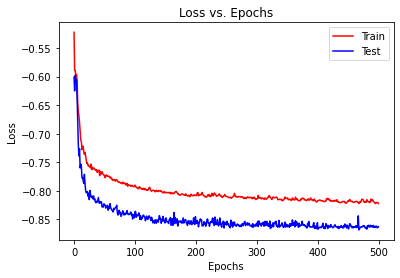

In [54]:
plt.plot(hist.history['loss'], color='red', label='Train')
plt.plot(hist.history['val_loss'], color='blue', label='Test')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc="upper right")
plt.title('Loss vs. Epochs')
plt.show()

In [55]:
model.save_weights(checkpoint_path)

In [22]:
checkpoint_path = "./check_points/0704r1_cp.ckpt"
model.load_weights(checkpoint_path)

In [7]:
output = model.predict(sample_loader)
moved = output['moved']
deformation = output['deformation']

In [56]:
# Voxel Affine 저장 ###########
output = model.predict(sample_loader)
moved = output['moved']
moved = moved * (max_value - min_value) + min_value

a = 1
j = 0
for i in range (0, 39):
    filename = "./BTCV_Data/gt_resize/" + str(a) + ".nii.gz"
    if os.path.isfile(filename):
        
        x = moved[j]
        x = np.squeeze(x)
        x = x.swapaxes(0,2) 
        print(a, ":", x.shape )
        savename = "./BTCV_Data/6.최종결과_resize10/" + str(a) + ".nii.gz"
        x = nib.Nifti1Image(x, None) 
        nib.save(x,savename)
        
        j += 1
        
    a += 1

1 : (128, 128, 64)
2 : (128, 128, 64)
3 : (128, 128, 64)
4 : (128, 128, 64)
5 : (128, 128, 64)
6 : (128, 128, 64)
7 : (128, 128, 64)
8 : (128, 128, 64)
9 : (128, 128, 64)
10 : (128, 128, 64)
21 : (128, 128, 64)
22 : (128, 128, 64)
23 : (128, 128, 64)
24 : (128, 128, 64)
25 : (128, 128, 64)
26 : (128, 128, 64)
27 : (128, 128, 64)
28 : (128, 128, 64)
29 : (128, 128, 64)
30 : (128, 128, 64)
31 : (128, 128, 64)
32 : (128, 128, 64)
33 : (128, 128, 64)
34 : (128, 128, 64)
35 : (128, 128, 64)
36 : (128, 128, 64)
37 : (128, 128, 64)
38 : (128, 128, 64)
39 : (128, 128, 64)


In [23]:
# Voxelmorph GT 저장 ###########
output = model.predict(sample_loader)
deformations = output['deformation']

a = 1
j = 0
for i in range (0, 39):
    filename = "./BTCV_Data/gt_change/" + str(a) + ".nii.gz"
    
    if os.path.isfile(filename):
#         print(gt_moving.shape)
        gt_moving = nib.load(filename).get_fdata()
        gt_moving = gt_moving.swapaxes(0,2)
        gt_moving = tf.expand_dims(gt_moving, axis=0)
        gt_moving = tf.expand_dims(gt_moving, axis=4)
        #print(gt_moving.shape)
        deformation = deformations[j]
        
        nd, nh, nw, nc = tf.shape(deformation)
#         print(deformation.shape)
        # Regular grid.
        grid = regular_grid_3d(nd, nh, nw)

        grid = tf.expand_dims(grid, axis=0) 
        multiples = tf.stack([1, 1, 1, 1, 1])
        grid = tf.tile(grid, multiples)

        #print(deformation.shape)
        grid_new = grid + deformation
        grid_new = tf.clip_by_value(grid_new, -1, 1)

        gt_moving = tf.cast(gt_moving, tf.float32)

        gt = grid_sample_3d(gt_moving, grid_new, name='gt')
        #print(gt.shape)
        gt = gt[0].numpy()
        gt = gt.squeeze()
        #print(gt.shape)
        gt = gt.swapaxes(0,2)
        x = nib.Nifti1Image(gt, None) 
        nib.save(x,"./BTCV_Data/gt_voxelmorph_r1/" +str(a)+ ".nii.gz")
        
        j += 1
        
    a += 1

In [8]:
deformation.shape

(29, 64, 128, 128, 3)

In [55]:
gt_moved.shape

(128, 128, 64)

In [10]:
filename = "./BTCV_Data/gt_affine/1.nii.gz"

gt_moving = nib.load(filename).get_fdata()
gt_moving = gt_moving.swapaxes(0,2)
gt_moving = tf.expand_dims(gt_moving, axis=0)
gt_moving = tf.expand_dims(gt_moving, axis=4)
print(gt_moving.shape)

nb, nd, nh, nw, nc = tf.shape(deformation)

# Regular grid.
grid = regular_grid_3d(nd, nh, nw)

grid = tf.expand_dims(grid, axis=0) 
multiples = tf.stack([nb, 1, 1, 1, 1])
grid = tf.tile(grid, multiples)

print(deformation[0].shape)
grid_new = grid + deformation[0]
grid_new = tf.clip_by_value(grid_new, -1, 1)

gt_moving = tf.cast(gt_moving, tf.float32)

gt = grid_sample_3d(gt_moving, grid_new, name='gt')
print(gt.shape)
gt = gt[0].numpy()
gt = gt.squeeze()
print(gt.shape)
gt = gt.swapaxes(0,2)
x = nib.Nifti1Image(gt, None) 
nib.save(x,'./BTCV_Data/gt_voxel최종1.nii.gz')

(1, 64, 128, 128, 1)
(64, 128, 128, 3)
(19, 64, 128, 128, 1)
(64, 128, 128)


In [10]:
result = model.evaluate(sample_loader)

1/1 [==============================] - 0s 956us/step - loss: -0.5884 - deformation_loss: 0.0041 - tf_op_layer_moved_loss: -0.5892


In [11]:
moved = moved * max_value
print(moved.shape)
a = moved[0]
b = deformation[0]

print(a.shape)
a = a.swapaxes(0,2) 
b = b.swapaxes(0,2) conv10
print(a.shape)

a = nib.Nifti1Image(a,None) 
b = nib.Nifti1Image(b,None)

nib.save(a,'chaos_train_voxel/moved_.nii.gz')
nib.save(b,'chaos_train_voxel/deformation_.nii.gz')

(19, 64, 128, 128, 1)
(64, 128, 128, 1)
(128, 128, 64, 1)


In [2]:
def dice_coef(y_true, y_pred_bin):
                    
    intersection = 2.0 * np.sum(y_true * y_pred_bin)
    union = (np.sum(y_true) + np.sum(y_pred_bin))
    if union == 0:
        return 0
    return (intersection / union)

def dice_coef_multilabel(y_true, y_pred, labels=11):
    w,h,d = y_true.shape
    result = 0
    union = (np.sum(y_pred) + np.sum(y_true))
    #print("union:" + str(union))
    intersection = 0
    for m in range(1,labels+1):
        intersection += np.sum(y_pred[y_true==m])*2.0 
    
        #print("label: "+ str(m) +" intersection: "+str(np.sum(y_pred[y_true==m])*2.0 ))
    dice = intersection / union
#     print("result: "+ str(dice))        
    
    return round(dice,2)

In [3]:
aaa = 1
for i in range (0, 39):
    #filename1 = "./BTCV_Data/gt_resize/" + str(aaa) + ".nii.gz"
    filename1 = "./BTCV_Data/gt_resize/40.nii.gz"
    filename2 = "./BTCV_Data/gt_change_vox_r10/" + str(aaa) + ".nii.gz"
    if os.path.isfile(filename2):
        print("Name: " + str(aaa))
        x1 = nib.load(filename1).get_fdata()
        x1 = x1.astype(np.float32)
        x2 = nib.load(filename2).get_fdata()
        x2 = x2.astype(np.float32)
        # print(x1.shape)
        print("Result Dice: "+ str(dice_coef_multilabel(x1,x2,11)))
    
    aaa += 1

Name: 1
Result Dice: 0.11
Name: 2
Result Dice: 0.07
Name: 3
Result Dice: 0.01
Name: 4
Result Dice: 0.19
Name: 5
Result Dice: 0.04
Name: 6
Result Dice: 0.15
Name: 7
Result Dice: 0.02
Name: 8
Result Dice: 0.01
Name: 9
Result Dice: 0.18
Name: 10
Result Dice: 0.0
Name: 21
Result Dice: 0.0
Name: 22
Result Dice: 0.45
Name: 23
Result Dice: 0.02
Name: 24
Result Dice: 0.17
Name: 25
Result Dice: 0.0
Name: 26
Result Dice: 0.4
Name: 27
Result Dice: 0.47
Name: 28
Result Dice: 0.29
Name: 29
Result Dice: 0.2
Name: 30
Result Dice: 0.05
Name: 31
Result Dice: 0.23
Name: 32
Result Dice: 0.01
Name: 33
Result Dice: 0.38
Name: 34
Result Dice: 0.03
Name: 35
Result Dice: 0.38
Name: 36
Result Dice: 0.03
Name: 37
Result Dice: 0.47
Name: 38
Result Dice: 0.32
Name: 39
Result Dice: 0.0


In [21]:
gt_moved = gt_moved.swapaxes(0,2)

c = nib.Nifti1Image(gt_moved, None)
nib.save(c,'0530 결과/gt0530_04.nii.gz')